In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import seaborn as sns
import glob

In [2]:
file = './Faceshouses/ap_faceshouses.mat'

In [3]:
ecog = loadmat(file)
data = ecog['data']
stim = ecog['stim']

In [4]:
data.shape

(268400, 41)

In [5]:
stim.shape

(268400, 1)

## AUXILIARY FUNCTIONS

In [6]:
def car(data):
    """
    Common Average Reference
    data: (time, channels)
    returns: (time, channels)
    """
    return data - data.mean(axis=1, keepdims=True)

In [7]:
import numpy as np

def fh_get_events(stim):
    """
    Python version of MATLAB fh_get_events.

    stim: array-like, shape (T,) or (T,1)
          stimulus code at each time sample

    returns:
      evs: ndarray, shape (n_events, 3)
           col0 = segment start index (0-based in Python)
           col1 = segment midpoint index
           col2 = class label: 0=ISI, 1=house, 2=face
    """
    stim = np.asarray(stim).squeeze() # .squeeze() makes our stim matrix in a 1D matrix
    if stim.ndim != 1:
        raise ValueError("stim must be 1D after squeeze()")

    T = stim.shape[0] # saving the time samples using the first column of stim

    # MATLAB: b = find((stim - [0; stim(1:end-1)]) ~= 0);
    prev = np.concatenate(([0], stim[:-1]))
    b = np.where((stim - prev) != 0)[0]  # 0-based indices

    if b.size < 2:
        return np.empty((0, 3), dtype=int)

    # MATLAB: c = floor(diff(b)/2);
    c = np.floor(np.diff(b) / 2).astype(int)

    # MATLAB: b(end) = [];
    b2 = b[:-1]

    # MATLAB: d = b + c;
    d = b2 + c

    # Build evs
    evs = np.zeros((len(b2), 3), dtype=int)
    evs[:, 0] = b2
    evs[:, 1] = d
    evs[:, 2] = stim[d].astype(int)

    # MATLAB: evs(find(evs(:,3)==0),:)=[];
    evs = evs[evs[:, 2] != 0]

    # MATLAB label remapping:
    # evs(find(evs(:,3)<51),3)=1;
    # evs(find(evs(:,3)==101),3)=0;
    # evs(find(evs(:,3)>50),3)=2;
    labels = evs[:, 2]
    labels[labels < 51] = 1
    labels[labels == 101] = 0
    labels[labels > 50] = 2
    evs[:, 2] = labels

    # clip if too close to ends of run files
    # MATLAB: evs(find(or(evs(:,1)<500, evs(:,2)>(length(stim)-1000))),:)=[];
    evs = evs[(evs[:, 0] >= 500) & (evs[:, 1] <= (T - 1000))]

    return evs


In [8]:
import numpy as np

def calc_dg_spectra(data, pts, samplefreq=1000, bsize=1000):
    """
    Python translation of calc_dg_spectra.m (ignoring commented lines).

    Parameters
    ----------
    data : ndarray, shape (T, C)
        CAR'd ECoG voltage (time x channels).
    pts : ndarray, shape (n_events, 3)
        Output of fh_get_events. Uses pts[:,1] as the midpoint time index.
        (Python 0-based indices.)
    samplefreq : int
        Sampling frequency (Hz). Default 1000.
    bsize : int
        Window length for spectrum (samples). Default 1000.

    Returns
    -------
    spectra : ndarray, shape (300, C, n_events)
        Power spectra snapshots: approx 1..300 Hz bins (DC removed).
    """
    data = np.asarray(data, dtype=float)
    pts = np.asarray(pts)
    T, C = data.shape
    n_events = pts.shape[0]

    half = bsize // 2  # 500 for bsize=1000

    # Pre-allocate: (freq_bins=300, channels, events)
    spectra = np.zeros((300, C, n_events), dtype=float)

    # FFT frequency bins for rfft with n=bsize at fs=1000 are 0..500 Hz in 1 Hz steps
    # We will take bins 1..300 -> frequencies 1..300 Hz (skipping DC bin 0)
    freq_idx = np.arange(1, 301)  # 1..300 inclusive

    for k in range(n_events):
        mid = int(pts[k, 1])  # midpoint index (0-based)

        start = mid - half
        stop  = mid + half  # exclusive, length bsize

        # (bsize, C)
        seg = data[start:stop, :]

        if seg.shape[0] != bsize:
            # Shouldn't happen because fh_get_events clips edges, but keep it safe
            continue

        # Compute rFFT along time axis for all channels at once
        X = np.fft.rfft(seg, n=bsize, axis=0)  # shape (501, C)

        # Power spectrum (no windowing, matching active MATLAB line that uses psd)
        P = (np.abs(X) ** 2)  # shape (501, C)

        # Keep bins 1..300 (skip DC bin 0)
        spectra[:, :, k] = P[freq_idx, :]

    return spectra


In [9]:
def calc_nspectra(spectra, eps=1e-12):
    """
    Python translation of calc_nspectra.m

    spectra: ndarray, shape (n_freq=300, n_channels, n_events)
             raw power spectra from calc_dg_spectra

    returns:
      nspectra: ndarray, same shape
                nspectra[:,k,e] = log( spectra[:,k,e] / mean_e spectra[:,k,e] )
    """
    spectra = np.asarray(spectra, dtype=float)

    # mean over events (axis=2) -> shape (n_freq, n_channels)
    mean_spec = spectra.mean(axis=2)

    # replicate across events via broadcasting -> (n_freq, n_channels, n_events)
    ratio = spectra / (mean_spec[:, :, None] + eps)

    # log transform
    nspectra = np.log(ratio + eps)

    return nspectra

In [10]:
import numpy as np

def dg_pca_step(spectra):
    """
    Python translation of dg_pca_step.m.

    Parameters
    ----------
    spectra : ndarray, shape (300, nc, n_events)
        Normalized spectra (output of calc_nspectra).

    Returns
    -------
    pc_weights : ndarray, shape (ncomps, nc, n_events)
        Projection weights of each event spectrum onto each PC (per channel).
    pc_vecs : ndarray, shape (ncomps, nc, ncomps)
        PC vectors (per channel), each is a vector across the kept frequencies.
        This matches MATLAB pc_vecs(:,chan,:) = vecs(:,1:ncomps)'.
    pc_vals : ndarray, shape (ncomps, nc)
        Eigenvalues (variance) per PC per channel, sorted descending.
    f : ndarray, shape (ncomps,)
        Kept frequency-bin indices in the MATLAB convention (1..300).
    """
    spectra = np.asarray(spectra, dtype=float)
    n_freq_all, nc, n_events = spectra.shape
    if n_freq_all != 300:
        raise ValueError(f"Expected spectra.shape[0] == 300, got {n_freq_all}")

    # --- build f exactly like MATLAB (but as 0-based indices for slicing) ---
    f_matlab = np.arange(1, 301)  # 1..300

    no60 = []
    max_k = int(np.ceil(f_matlab.max() / 60.0))
    for k in range(1, max_k + 1):
        no60.extend(range(60 * k - 3, 60 * k + 4))  # inclusive of +3
    no60.extend(range(247, 254))  # 247..253 inclusive

    no60 = set(no60)

    # setdiff + remove >200
    f_keep = np.array([ff for ff in f_matlab if (ff not in no60) and (ff <= 200)], dtype=int)

    # MATLAB uses these as frequency bins; we need 0-based indices to slice spectra
    f_idx = f_keep - 1
    ncomps = len(f_keep)

    # --- initialize outputs ---
    pc_weights = np.zeros((ncomps, nc, n_events), dtype=float)
    pc_vecs    = np.zeros((ncomps, nc, ncomps), dtype=float)
    pc_vals    = np.zeros((ncomps, nc), dtype=float)

    # --- channel-wise PCA ---
    for chan in range(nc):
        # ts: (n_freq_kept, n_events)
        ts = spectra[f_idx, chan, :]

        # covariance-like matrix: (n_freq_kept, n_freq_kept)
        M = ts @ ts.T

        # eigen-decomposition (symmetric)
        vals, vecs = np.linalg.eigh(M)  # vals ascending

        # sort descending (MATLAB does this)
        order = np.argsort(vals)[::-1]
        vals = vals[order]
        vecs = vecs[:, order]

        # projections: (ncomps, n_events)
        W = vecs[:, :ncomps].T @ ts

        # store (match MATLAB layout)
        pc_weights[:, chan, :] = W
        pc_vecs[:, chan, :]    = vecs[:, :ncomps].T
        pc_vals[:, chan]       = vals[:ncomps]

    return pc_weights, pc_vecs, pc_vals, f_keep

## CODE

In [11]:
data = car(data)
data.shape

(268400, 41)

In [12]:
pts = fh_get_events(stim)
pts.shape

(603, 3)

In [13]:
spectra = calc_dg_spectra(data, pts)
spectra.shape  # should be (300, n_channels, n_events)

(300, 41, 603)

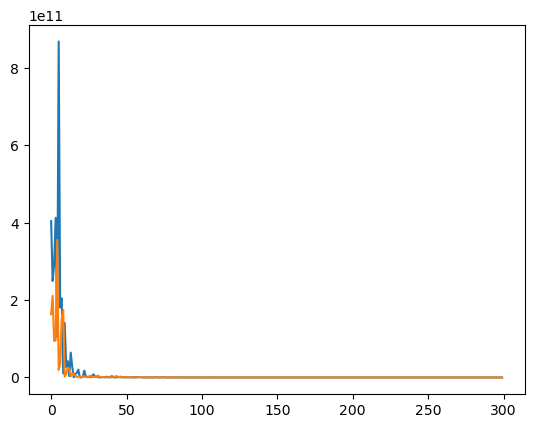

In [14]:
plt.plot(spectra[:,0,1]) # electrode 0, events 1 and 3
plt.plot(spectra[:,0,3])

In [15]:
nspectra = calc_nspectra(spectra)
nspectra.shape

(300, 41, 603)

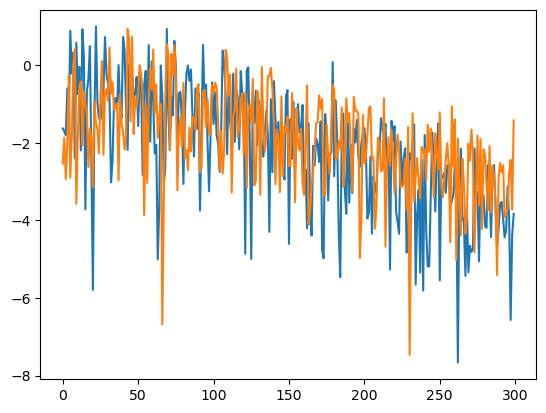

In [16]:
plt.plot(nspectra[:,0,1])
plt.plot(nspectra[:,0,3])

In [17]:
# pca taken at each electrode, so 46 in total
pc_weights, pc_vecs, pc_vals, f = dg_pca_step(nspectra)

print(pc_weights.shape)  # (len(f), nc, n_events)
print(pc_vecs.shape)     # (len(f), nc, len(f))
print(pc_vals.shape)     # (len(f), nc)

(179, 41, 603)
(179, 41, 179)
(179, 41)


In [18]:
# frequencies that we will be keeping, there are gaps around 55,64 - 116,124 - 176,184
f

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  64,  65,  66,  67,  68,  69,  70,  71,  72,
        73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,  84,  85,
        86,  87,  88,  89,  90,  91,  92,  93,  94,  95,  96,  97,  98,
        99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111,
       112, 113, 114, 115, 116, 124, 125, 126, 127, 128, 129, 130, 131,
       132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144,
       145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157,
       158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170,
       171, 172, 173, 174, 175, 176, 184, 185, 186, 187, 188, 189, 190,
       191, 192, 193, 194, 195, 196, 197, 198, 199, 200])

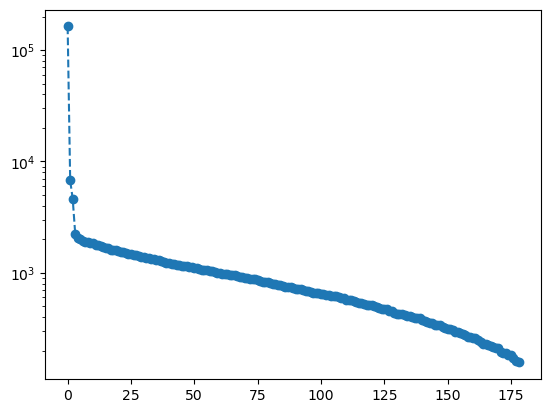

In [19]:
plt.semilogy(pc_vals[:,0],'o--')

It can be seen the 1st PC is the dominating factor, with the second one two orders of magnitude lower. 

In [20]:
# sanity check
ch = 2
f_idx = f - 1
ts = nspectra[f_idx, ch, :]
V = pc_vecs[:,ch,:]
W = pc_weights[:,ch,:]
np.linalg.norm(ts - V.T.dot(W))

np.float64(1.0371705916574284e-12)

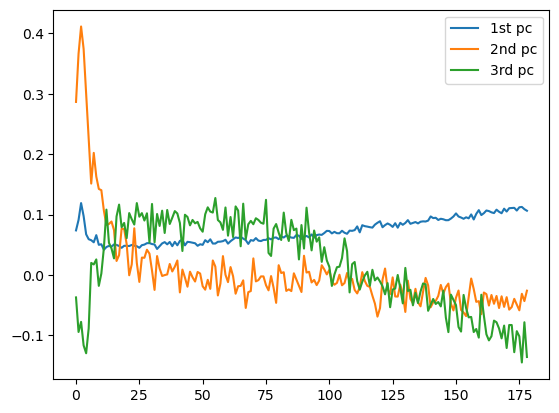

In [21]:
# first three principal component
plt.plot(pc_vecs[0,0,:],label='1st pc')
plt.plot(pc_vecs[1,0,:],label='2nd pc')
plt.plot(pc_vecs[2,0,:],label='3rd pc')
plt.legend()

Note the shapes of the principal components. Our 1st PC is pretty constant. This lines up with the paper from Miller. If the weight of this component is positive, it will shift it up, if it is negative it will shift it down

In [22]:
# 1st PC weights (for each electrode)
k = 0 # electrode
pc_weights[0,k,:].shape # taking the weights for electrode k for all 603 events

(603,)

We get one number for each event, so 603 of them. These will be the columns for our electrode, events dataframe

In [23]:
k = len(data[0])
df = np.zeros((603,k))
events = 603
for i in range(k):
    df[:,i] = pc_weights[0,i,:]
df = pd.DataFrame(df)

#### Correlation Matrix

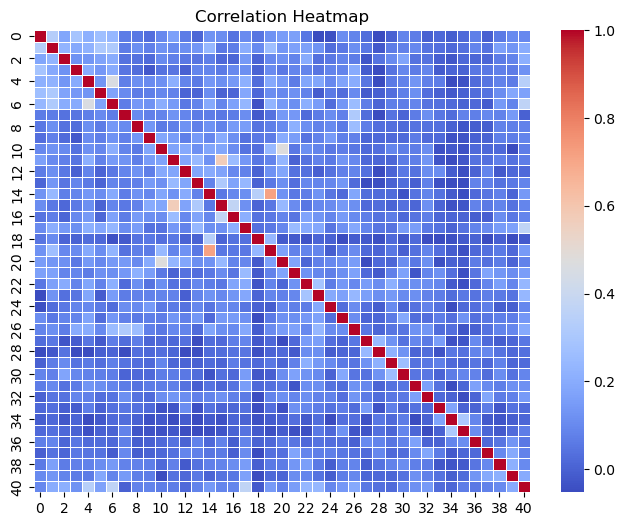

In [24]:
# using pandas .corr()
corr_mat = df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_mat, annot=False, cmap="coolwarm", fmt=".2f", linewidths=0.5,robust=True)
plt.title("Correlation Heatmap")
plt.show()

In [25]:
# loading all files
files = glob.glob('./Faceshouses/*.mat')
loc_files = glob.glob('./Locs/*.mat')

locs = []
for i in range(len(loc_files)):
    locs.append(loadmat(loc_files[i]))
ecogs = []
for i in range(len(files)):
    ecog = loadmat(files[i])
    ecogs.append(ecog['data'])

In [26]:
lam = 20

loc_all = []
for i in range(len(loc_files)):
    file = loc_files[i]
    loc = locs[i]['locs']
    loc_all.append(loc)
    all_locs = np.vstack(loc_all)

elec_total = 0
for i in range(len(files)):
    file = files[i]
    ecog = loadmat(file)
    data = ecog['data']
    elec_total += len(data[0])
print('Hello world')

Hello world


In [27]:
from scipy.spatial import distance
distances = distance.cdist(all_locs,all_locs, 'euclidean')
rbf = np.exp(-distances**2 / lam)
print('Hello world')

Hello world


In [28]:
print(
    rbf.shape,
    distances.shape)
print('Hello world')

(714, 714) (714, 714)
Hello world


In [29]:
def corr_mat(ecog,patient):
    patient = files[patient]
    ecog = ecogs[ecog]
    data = ecog['data']
    df = pd.DataFrame(data)
    corr_mat = df.corr()
    return corr_mat

def corr_plot(corr_mat):
    plt.figure(figsize=(8,6))
    sns.heatmap(corr_mat, annot=False, cmap="coolwarm", fmt=".2f", linewidths=0.5,robust=True)
    plt.title("Correlation Heatmap")
    plt.show()
print('Hello world')

Hello world


Note that the above parameters, ecog & patient, should be matching e.g (0,0), (1,1) as both arrays that the parameters pull from were initializing in the same order, so ecogs[0] is to be paired with files[0] and so on.

From Tara's Code

In [38]:
#Step one: apply the butternotch filter!
from scipy import signal

sos = signal.butter(4, [59.5, 60.5], btype='bandstop', analog=False, 
                        output='sos', fs=1000)

filtered = []
for file in ecogs:
    filtered.append(signal.sosfiltfilt(sos, file))

In [39]:
#Step two: kurtosis
from scipy.stats import kurtosis
cleaned = []
kept_global_indices = []
mapping_clean = []
electrode_offset = 0

for i, file in enumerate(filtered):
    n_electrodes = file.shape[1]
    
    k = kurtosis(file, axis=0)
    good_idx = np.where(k <= 10)[0]
    
    cleaned_file = file[:, good_idx]
    cleaned.append(cleaned_file)
    
    global_good_idx = good_idx + electrode_offset
    kept_global_indices.extend(global_good_idx)
    electrode_offset += n_electrodes
    
    for j in range(len(good_idx)):  # number of KEPT electrodes
        mapping_clean.append([len(mapping_clean), i])  # i = subject index

mapping_clean = np.array(mapping_clean)
kept_global_indices = np.array(kept_global_indices)
xyz_clean = all_locs[kept_global_indices]

print(xyz_clean.shape)        # (n_kept_electrodes, 3)
print(mapping_clean.shape)    # (n_kept_electrodes, 2)

(649, 3)
(649, 2)


In [40]:
# drop <2 electrodes, not modified since it didn't change anything
dropped = []
for file in cleaned:
    if file.shape[1] >1:
        dropped.append(file)

In [88]:
def r(z):
    if isinstance(z, list):
        z = np.array(z)

    r = (np.exp(2*z) - 1) / (np.exp(2*z) + 1)
    
    if isinstance(r, np.ndarray):
        r[np.isinf(z) & (z > 0)]: 1 
        r[np.isinf(z) & (z < 0)]: -1
    else:
        if np.isinf(z) & (z > 0):
            return 1
        elif np.isinf(z) & (z < 0):
            return -1
    return r
    
def z(input2):
    z = .5 * (np.log(1 + input2) - np.log(1 - input2))
    return z

In [97]:
corrnp = corr.to_numpy()
z(r(corrnp))

array([[1.        , 0.61014109, 0.51725033, ..., 0.48165671, 0.47558429,
        0.46219281],
       [0.61014109, 1.        , 0.70395345, ..., 0.33944016, 0.34157275,
        0.34105164],
       [0.51725033, 0.70395345, 1.        , ..., 0.43654317, 0.43579824,
        0.43608534],
       ...,
       [0.48165671, 0.33944016, 0.43654317, ..., 1.        , 0.95153865,
        0.91523782],
       [0.47558429, 0.34157275, 0.43579824, ..., 0.95153865, 1.        ,
        0.95650871],
       [0.46219281, 0.34105164, 0.43608534, ..., 0.91523782, 0.95650871,
        1.        ]])

In [64]:
#create RBF correlation matrix
# Euclidean distance matrix (714x714)
dist_matrix = distance.cdist(xyz_clean, xyz_clean, metric='euclidean')

# Gaussian RBF kernel: exp(-(epsilon * r)^2)
rbf_matrix = np.exp(-dist_matrix**2 / 20)

correlation_matrices = []
for i, matrix in enumerate(dropped):
    # Get electrode indices for this patient
    patient_electrode_indices = mapping_clean[mapping_clean[:, 1] == i, 0].astype(int)
    
    # Compute pairwise correlation between this patient's electrodes
    corr = pd.DataFrame(matrix).corr()
    # shape: (n_patient_elec x n_patient_elec)

    # RBF weights between ALL 649 electrodes and this patient's electrodes
    # W shape: (714 x n_patient_elec)
    W = rbf_matrix[:, patient_electrode_indices]

    # Equation (6): Cˆ(x,y) = sum_ij W(x,i)*W(y,j)*z(C̄s(i,j))
    #                        / sum_ij W(x,i)*W(y,j)
    # Vectorized: numerator = W @ z_corr @ W.T  →  (714 x 714)
    numerator   = W @ z(corr) @ W.T
    denominator = W @ np.ones_like(corr) @ W.T

    C_hat = r(np.divide(numerator, denominator, 
                         where=denominator != 0, 
                         out=np.zeros((649, 649))))

    correlation_matrices.append(C_hat)

K = r(np.average(z(np.stack(correlation_matrices, axis=0)), axis=0))

C:\Users\unrel\anaconda3\Lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)
C:\Users\unrel\anaconda3\Lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)
C:\Users\unrel\anaconda3\Lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)
C:\Users\unrel\anaconda3\Lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)
C:\Users\unrel\anaconda3\Lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)
C:\Users\unrel\anaconda3\Lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: divide by zero encountered in log
  result = func(self.valu

New vectorized Equation

In [53]:
correlation_matrices2 = []
for i, matrix in enumerate(dropped):
    # Get electrode indices for this patient
    patient_electrode_indices = mapping_clean[mapping_clean[:, 1] == i, 0].astype(int)
    
    # Compute pairwise correlation between this patient's electrodes
    corr = pd.DataFrame(matrix).corr()
    # shape: (n_patient_elec x n_patient_elec)

    # RBF weights between ALL 649 electrodes and this patient's electrodes
    # W shape: (714 x n_patient_elec)
    W = rbf_matrix[:, patient_electrode_indices]
    
    Z = z(corr)
    Z = np.tril(Z, k=0)

    # Numerator: W @ Z @ W.T
    num = W @ Z @ W.T          # (n_x, n_x)

    # Denominator: sum over i≠j W[x,i]W[y,j]
    mask = np.tril(np.ones_like(corr), k=0)
    denominator = W @ mask @ W.T

    # Safe division
    C_big = np.divide(
        numerator,
        denominator,
        out=np.zeros_like(numerator),
        where=denominator != 0
    )

    correlation_matrices2.append(C_big)


In [54]:
K = r(np.average(z(np.stack(correlation_matrices2, axis=0)), axis=0))
K.shape

(649, 649)

In [37]:
n_x, n_i = W.shape
C_big = np.zeros((649,649))

for x in range(n_x):
    print(x)
    for y in range(n_x):
        num = 0.0
        denom = 0.0
        for i in range(n_i):
            for j in range(n_i - 1):
                num = W[x,i] * W[y,j] * z(corr.iloc[i,j])
                denom = W[x,i] * W[y,j]
                
                if denom != 0:
                    C_big[x,y] = num / denom
                else: 
                    C_big[x,y] = 0.0
return C_big

0
1
2
3
4
5
6
7
8


KeyboardInterrupt: 

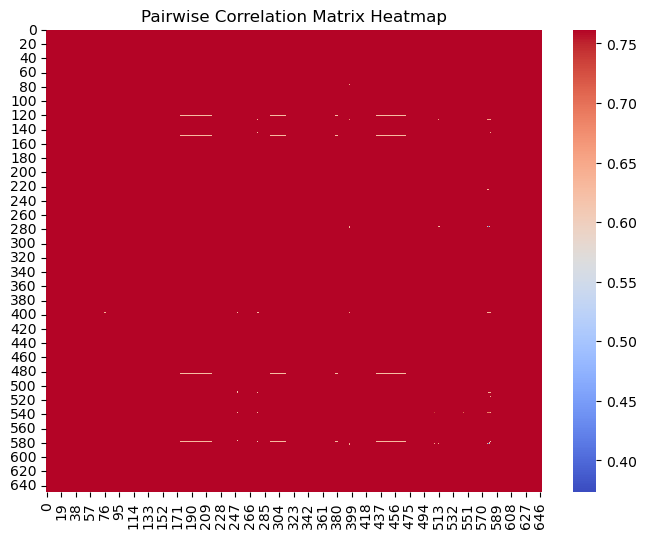

In [55]:
#Look at one patient
plt.figure(figsize=(8, 6))

sns.heatmap(K, cmap='coolwarm', fmt=".2f")

plt.title('Pairwise Correlation Matrix Heatmap')
plt.show()

In [ ]:
def single_patient_prediction(patient,electrodestart,electrodeend,ecogs,correlation_matrix):
    #this gets everything for this patient, the correlation of the observed and unobserved datapoints
    Y = ecogs[patient] #gets this paitents data
    row_means = np.mean(Y, axis=0, keepdims=True)
    row_stds = np.std(Y, axis=0, keepdims=True)
    Y_z_score = (Y - row_means) / row_stds #turns them into there z_score for each value in the data
    print('Y_z_score.shape')
    print(Y_z_score.shape)
    K_patient = correlation_matrix[:,electrodestart:electrodeend+1] #this gets all the electrodes that the patient has with their own correlation and that of others
    print('K_patient.shape')
    print(K_patient.shape)
    Kalpha_alpha = K_patient[electrodestart:electrodeend+1,:] #gets all the rows that the patient has observed data for
    print('Kalpha_alpha.shape')
    print(Kalpha_alpha.shape)
    Kbeta_alpha = K_patient[electrodeend+1:,:] #get all rows the patient doestn have observed 
    print('Kbeta_alpha.shape')
    print(Kbeta_alpha.shape)
    Y_patient = Y_z_score[:,electrodestart:electrodeend+1] #gets all the z_score values from electrodes the patient we did observed
    print('Y_patient.shape')
    print(Y_patient.shape)
    Y_true = Y_z_score[:,electrodeend+1:] #gets all the z_score values from electrodes the patient we didnt observed (for potential comparison later)
    print('Y_true.shape')
    print(Y_true.shape)
    Yt = Y_patient.T #take the transpose of it
    Kalpha_alpha_inv = np.linalg.inv(Kalpha_alpha) 
    pred = ((Kbeta_alpha@Kalpha_alpha_inv)@Yt).T #using formula from paper
    print('pred.shape')
    print(pred.shape)
    return pred, Y_true

In [ ]:
c_matrix = r(np.average(z(np.stack(correlation_matrices, axis=0)), axis=0))
c_matrix.shape

In [ ]:
pred,y_real = single_patient_prediction(0,0,10,ecogs,c_matrix)

In [ ]:
plt.plot(y_real[2000:4000,0])
print(y_real.shape)

In [ ]:
plt.plot(pred[2000:2500,0],label='pred')
plt.plot(y_real[2000:2500,0],label='real')
plt.legend()